In [2]:
import pandas as pd

df = pd.read_csv("../dataset/processed/model_ready_dataset.csv")

print(df.head())
print(df.shape)

                                             text                label  \
0       You need to choose me over everyone else.  Emotional Blackmail   
1               Nobody else thinks that happened.          Gaslighting   
2       I don't know why I bother trying anymore.       Guilt Tripping   
3  You should feel bad for treating me like this.       Guilt Tripping   
4       If you walk away, you'll lose me forever.  Emotional Blackmail   

   label_encoded  
0              3  
1              1  
2              2  
3              2  
4              3  
(250, 3)


In [3]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 200
Test: 50


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(200, 364)


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [6]:
predictions = model.predict(X_test_tfidf)

print(predictions)

[3 0 1 1 0 4 3 1 3 1 1 1 4 0 4 1 3 2 0 0 3 3 2 0 2 3 3 0 0 2 3 3 4 4 3 3 2
 4 2 1 4 4 3 1 2 1 0 2 2 1]


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.88


In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.91      1.00      0.95        10
           2       0.89      0.80      0.84        10
           3       0.77      1.00      0.87        10
           4       1.00      0.80      0.89        10

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50



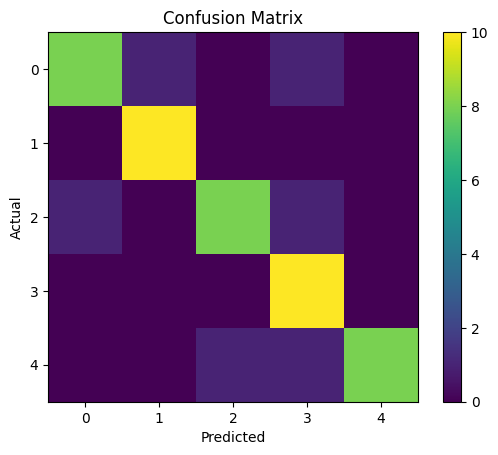

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.88


In [11]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.91      1.00      0.95        10
           2       0.89      0.80      0.84        10
           3       0.77      1.00      0.87        10
           4       1.00      0.80      0.89        10

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50

